### Produce the intersection of DEG plot

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
intersection_df  <- read.csv("01_intersect_analysis_results.csv", row.names = 1)
intersection_df %>% head()

,cell_type,contrast1,contrast2,up_both,down_both,up_1_down_2,down_1_up_2,consistent_ratio,z_score,p_value
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
0,Adipocyte,aging,disease,0,34,0,0,1.0000000,3.0256288,2.481167e-03
1,Cardiomyocyte,aging,disease,18,26,2,6,0.8461538,3.7376341,1.857600e-04
2,Cardiomyocyte,aging,development,6,21,17,33,0.3506494,-2.5770647,9.964330e-03
3,Cardiomyocyte,disease,development,442,339,219,103,0.7080689,13.3453561,1.000000e-16
4,Endocardial,aging,disease,0,1,0,0,1.0000000,4.1116086,3.929119e-05
5,Endocardial,aging,development,0,0,1,2,0.0000000,-0.7319798,4.641809e-01


In [3]:
intersection_df$contrast_pair <- paste0(intersection_df$contrast1, "-", intersection_df$contrast2)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_bar()`).”


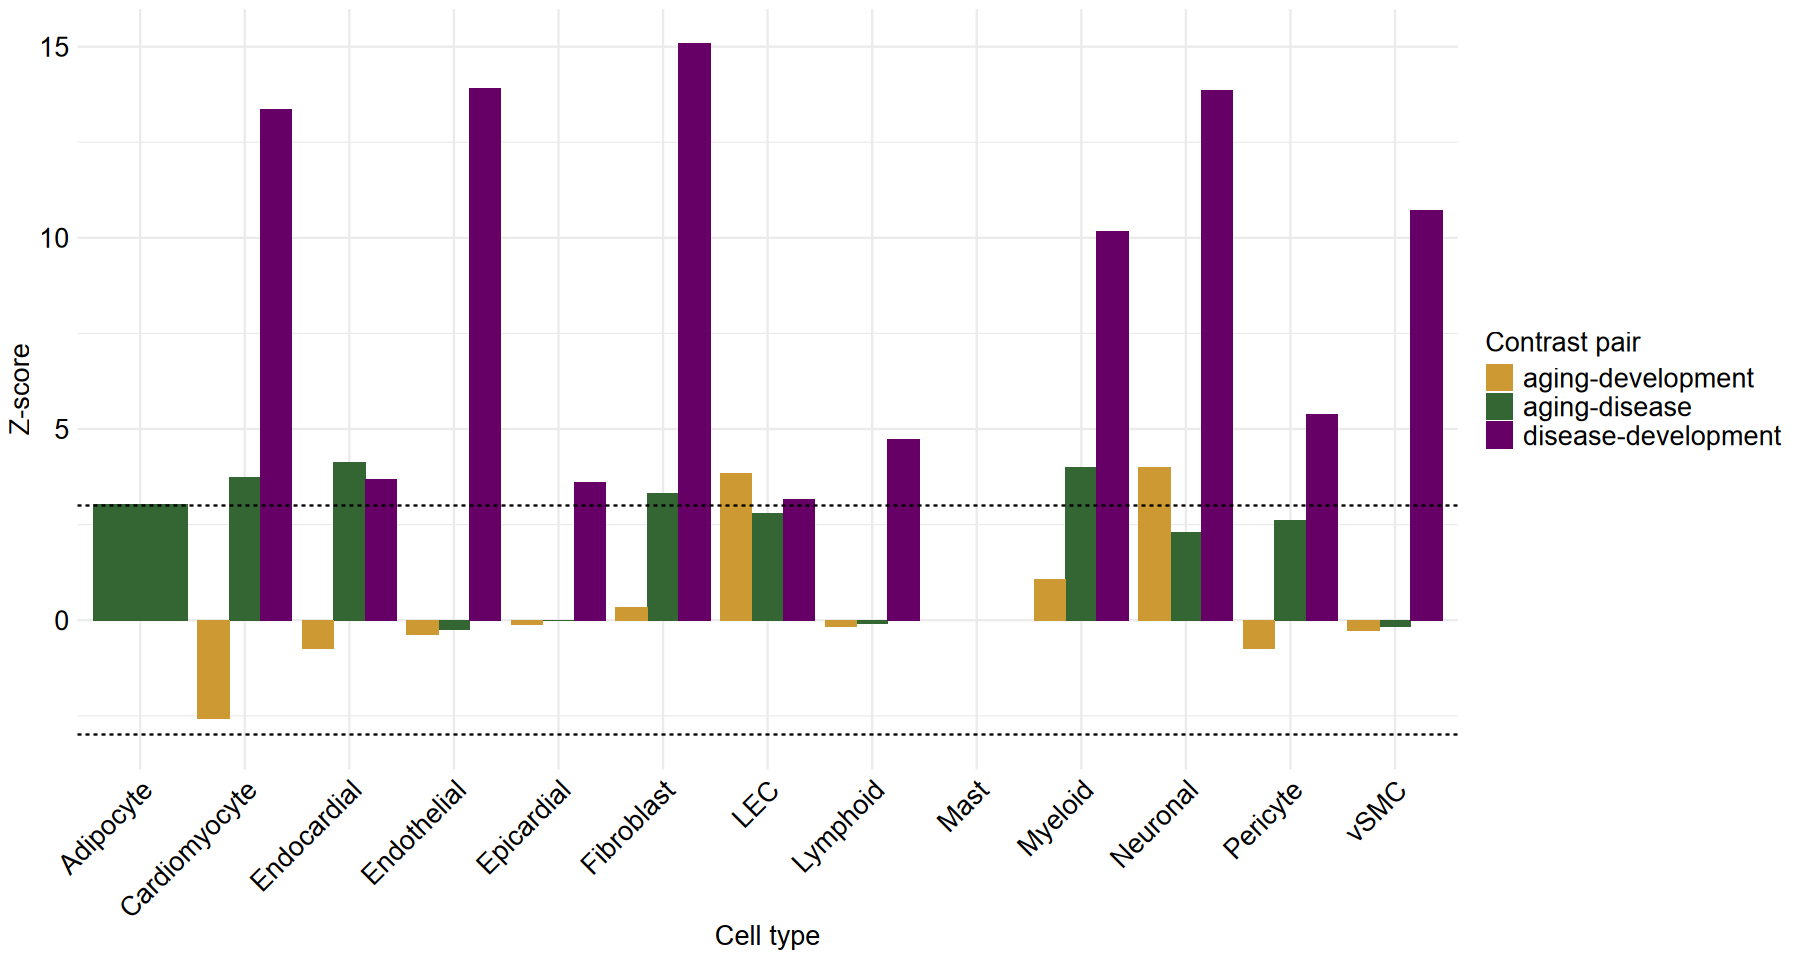

In [4]:
options(repr.plot.width = 15, repr.plot.height = 8)

p1 <- ggplot(data = intersection_df,
       mapping = aes(x = cell_type, y = z_score, fill = contrast_pair)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  scale_fill_manual(values = c(
    "aging-disease"   = "#336633",
    "aging-development"     = "#CC9933",
    "disease-development" = "#660066"
  )) +
  theme_minimal() + geom_hline(yintercept = 3, linetype = "dashed", color = "black") +
  geom_hline(yintercept = -3, linetype = "dashed", color = "black") +
  labs(x = "Cell type", y = "Z-score", fill = "Contrast pair") +
theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black", angle = 45, hjust = 1),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"))

ggsave(plot = p1, filename = "02_contrast_pairwise_z_score_plot.pdf", width = 15, height = 8)

p1